In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("final.csv")

In [3]:
df = df.dropna()

In [4]:
df.shape

(720000, 24)

In [5]:
df.head()

,Bank Name,City,Loan Amount,Credit Score,Interest Rate,Loan Tenure (Years),Age,Gender,Marital_Status,Dependents,...,Existing_Loans (count),Default_History,Property_Owned,Purpose_of_Loan,Collateral,Loan_Status,Loan-to-Value Ratio,Debt-to-Income Ratio,Approval Probability,Creditworthiness
0,State Bank of India (SBI),Pune,2087740.60,685,14.00,12,38,Female,Married,0,...,5,Yes,Flat,Travel,Fixed Deposit,Pending,0.36,0.69,0.81,Low
1,State Bank of India (SBI),Delhi,313264.26,854,11.92,24,54,Male,Single,4,...,5,Yes,House,Business Expansion,Property,Rejected,0.18,0.12,0.91,High
2,State Bank of India (SBI),Hyderabad,4551577.79,301,12.26,30,48,Male,Widowed,5,...,0,No,Flat,Business Expansion,Vehicle,Pending,0.82,0.74,0.59,Medium
3,State Bank of India (SBI),Pune,4130424.69,333,8.02,24,42,Other,Single,4,...,3,Yes,Flat,Travel,Vehicle,Pending,0.81,0.46,0.91,Medium
4,State Bank of India (SBI),Bengaluru,1070123.33,611,13.65,3,45,Female,Married,4,...,0,Yes,House,Travel,Fixed Deposit,Rejected,0.58,0.39,0.82,High


In [9]:
import seaborn as sns

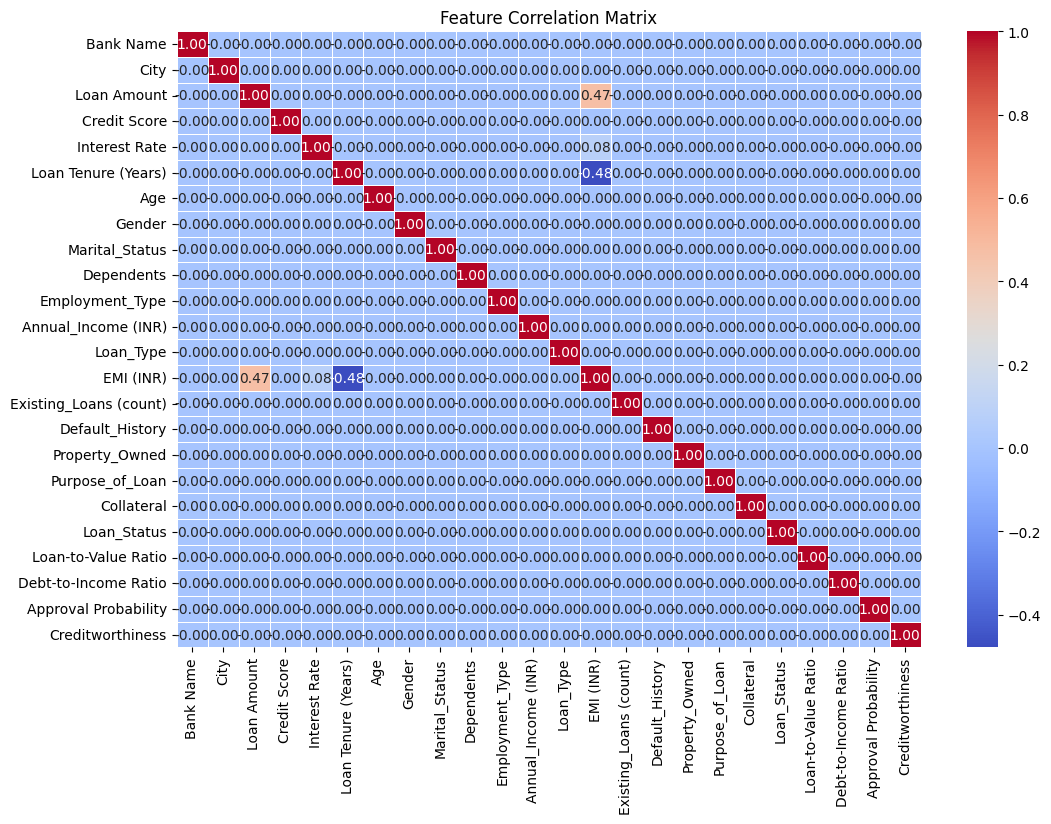

In [23]:
corr_matrix = df.corr()

# Plot the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()

In [12]:
df.describe()

,Loan Amount,Credit Score,Interest Rate,Loan Tenure (Years),Age,Dependents,Annual_Income (INR),EMI (INR),Existing_Loans (count),Loan-to-Value Ratio,Debt-to-Income Ratio,Approval Probability
count,7.200000e+05,720000.000000,720000.000000,720000.000000,720000.000000,720000.000000,7.200000e+05,720000.000000,720000.000000,720000.000000,720000.000000,720000.000000
mean,2.524083e+06,599.850379,10.747944,15.506237,43.970937,2.501899,2.598837e+06,42449.280974,2.497511,0.550454,0.449957,0.694552
std,1.428379e+06,173.645042,2.454116,8.657287,15.289667,1.706478,1.384752e+06,51134.255292,1.707642,0.259877,0.202146,0.170422
min,5.000266e+04,300.000000,6.500000,1.000000,18.000000,0.000000,2.000020e+05,341.200000,0.000000,0.100000,0.100000,0.400000
25%,1.286399e+06,449.000000,8.620000,8.000000,31.000000,1.000000,1.401302e+06,15767.740000,1.000000,0.330000,0.270000,0.550000
50%,2.523015e+06,600.000000,10.750000,16.000000,44.000000,3.000000,2.597454e+06,30937.030000,2.000000,0.550000,0.450000,0.690000
75%,3.761119e+06,750.000000,12.870000,23.000000,57.000000,4.000000,3.797108e+06,48740.570000,4.000000,0.780000,0.630000,0.840000
max,5.000000e+06,900.000000,15.000000,30.000000,70.000000,5.000000,4.999994e+06,450305.730000,5.000000,1.000000,0.800000,0.990000


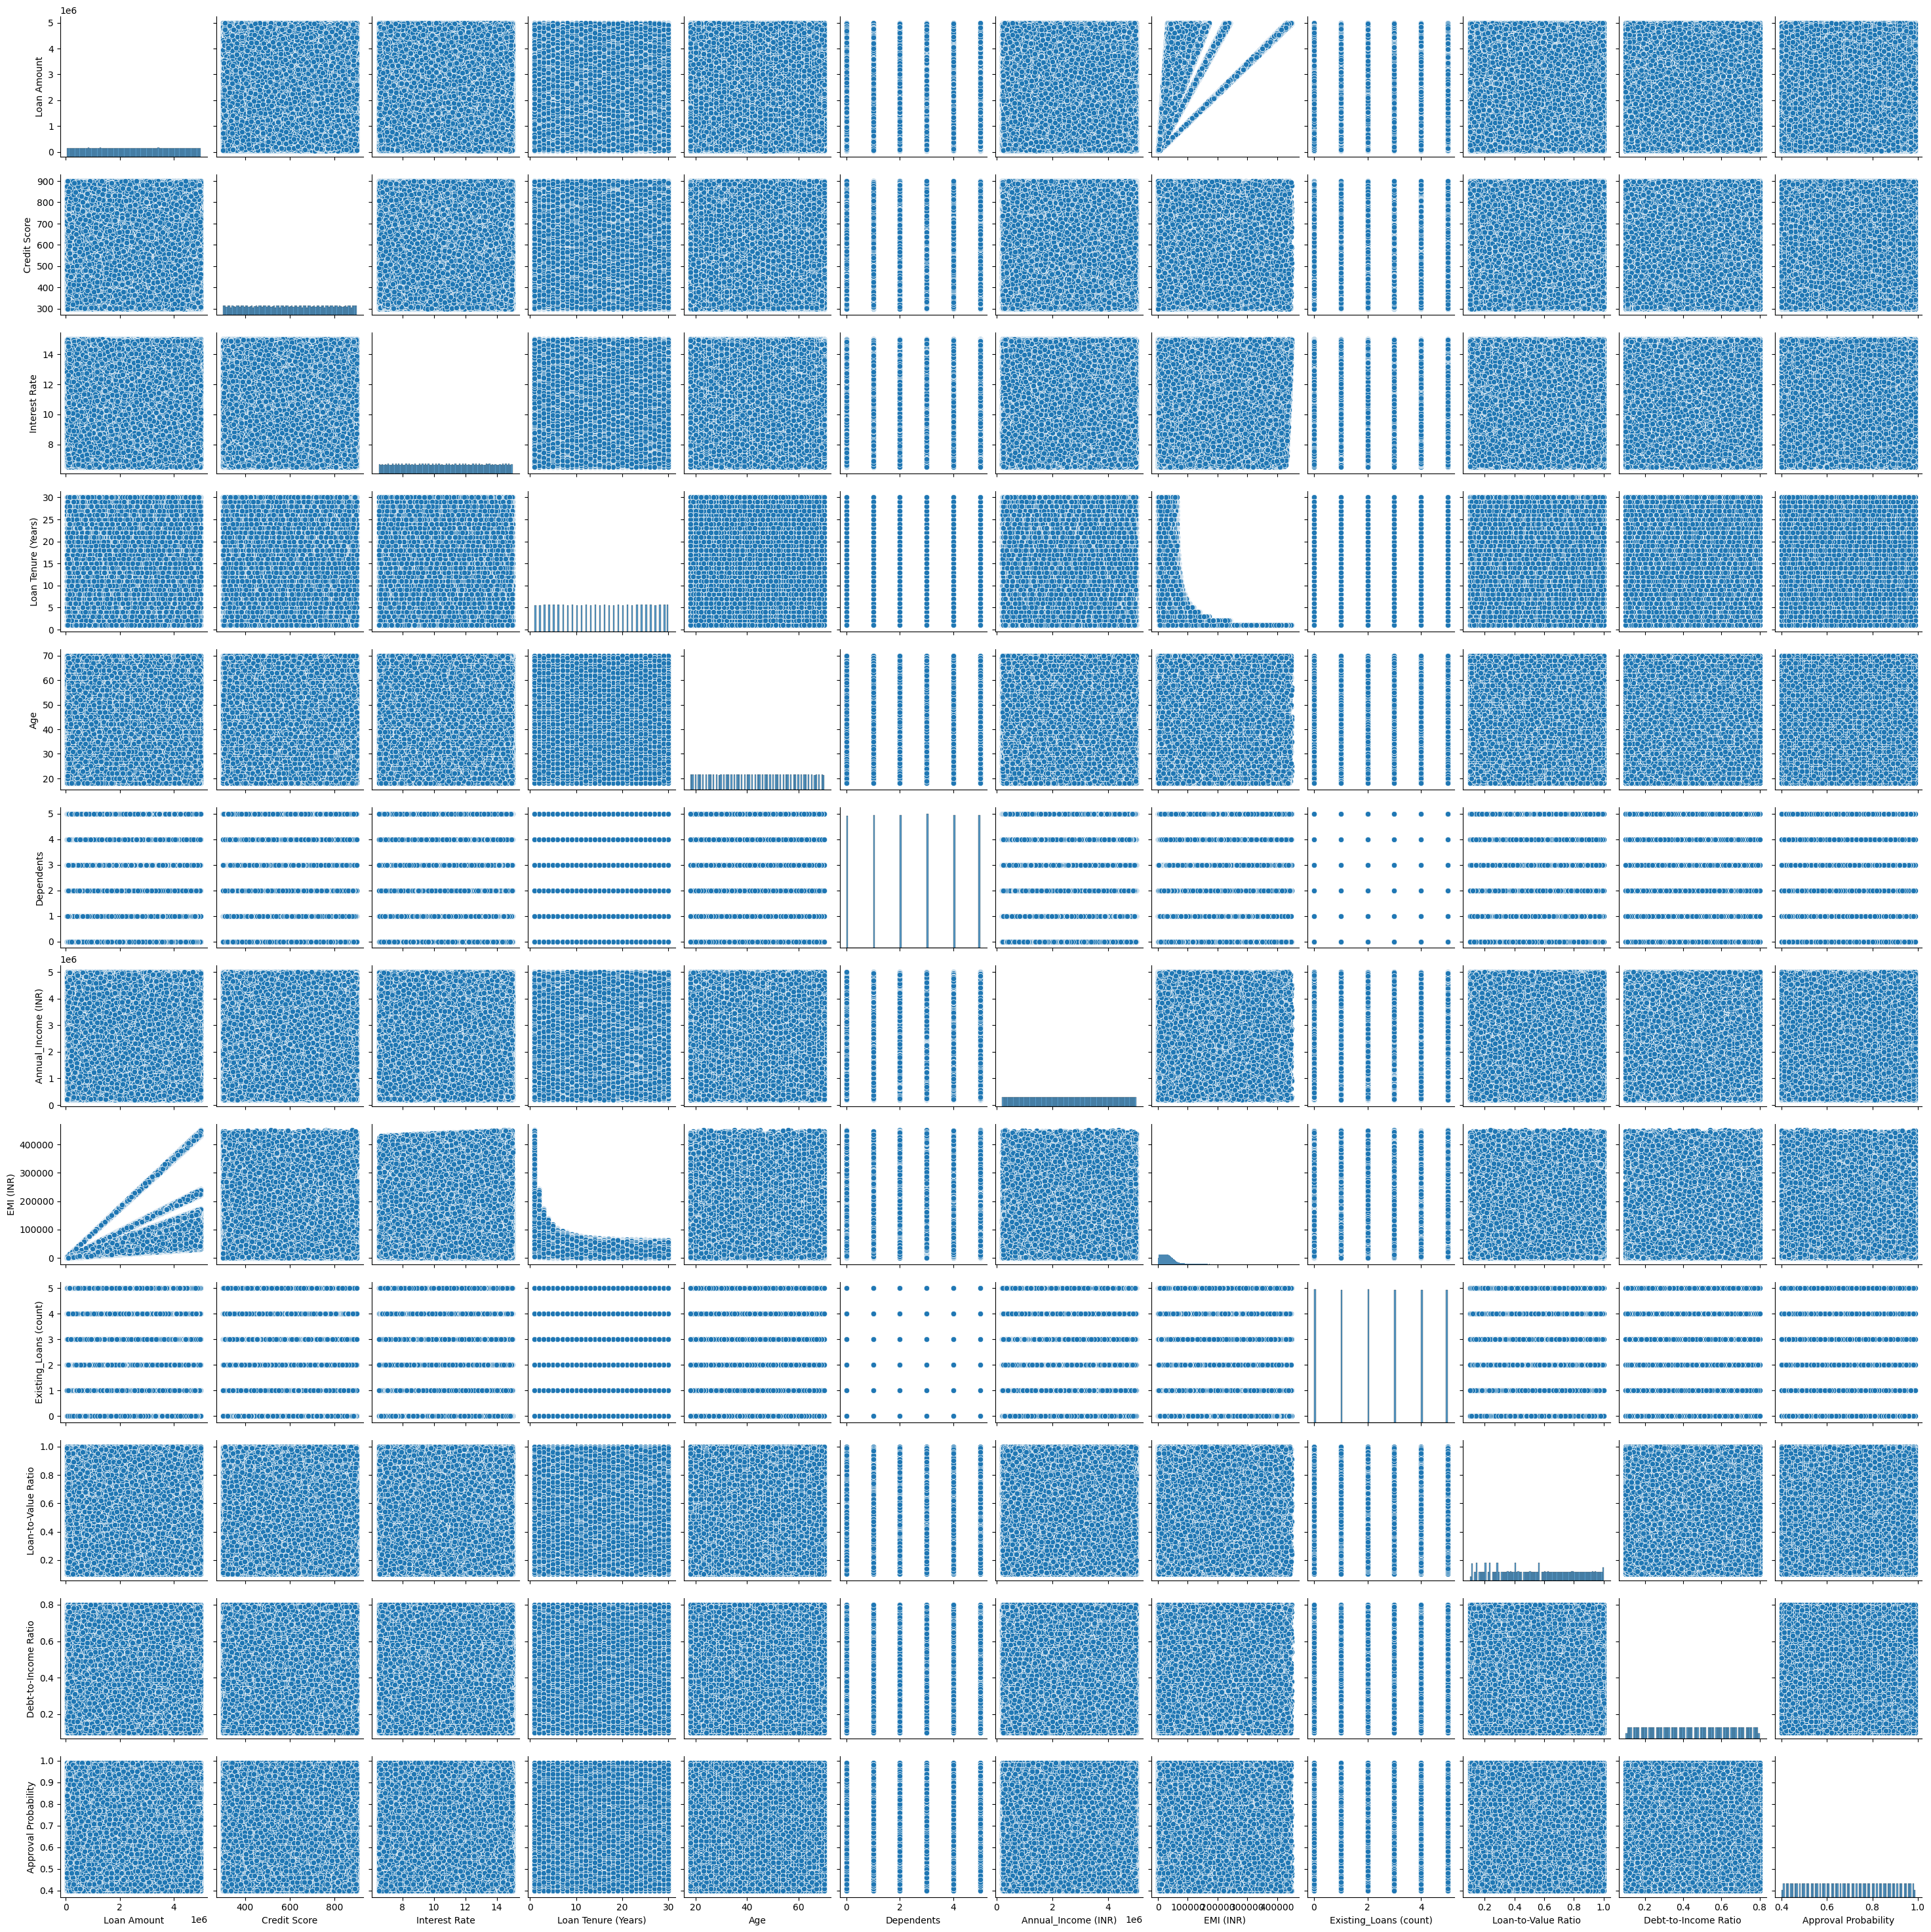

In [11]:
sns.pairplot(df)

In [17]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [18]:
label_encoders = {}

In [19]:
categorical_columns = ['City', 'Gender', 'Marital_Status', 'Employment_Type', 
                       'Loan_Type', 'Default_History', 'Property_Owned', 
                       'Purpose_of_Loan', 'Collateral', 'Loan_Status', 'Creditworthiness', 'Bank Name']


In [20]:
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # Store encoder for later use

In [63]:
df.isnull().sum().sum()

0

In [41]:
X = df.drop(columns=['Bank Name'])  # Features
y = df['Bank Name']  # Target

In [42]:
y.unique()

array([29, 26,  4,  5, 34, 15,  7,  9,  6, 32, 25, 16, 12, 13,  2, 21, 17,
       35, 11,  3, 14, 20, 27, 19,  0, 10, 33, 18, 30,  8, 23, 22, 24,  1,
       28, 31], dtype=int64)

In [43]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [44]:
from sklearn.model_selection import train_test_split

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [46]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [47]:
# rfc = RandomForestClassifier(n_estimators=100, random_state=42)

In [48]:
# rfc.fit(X_train, y_train)

In [49]:
# y_pred_rfc = rfc.predict(X_test)

In [50]:
# accuracy_score(y_test, y_pred_rfc)

In [51]:
# from sklearn.linear_model import SGDClassifier

In [52]:
# sgd_model = SGDClassifier(loss='log', max_iter=1000, random_state=42)

In [53]:
# sgd_model.fit(X_train, y_train)

In [54]:
# y_pred_sgd = sgd_model.predict(X_test)

In [55]:
# accuracy_score(y_test, y_pred_sgd)

In [56]:
from sklearn.decomposition import PCA

In [57]:
pca = PCA(n_components = 15)
x_train_pca = pca.fit_transform(X_train)
x_test_pca = pca.transform(X_test)

In [58]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [59]:
model2 = Sequential([
    Dense(2048, activation='relu', input_shape=(x_train_pca.shape[1],)),  # Input layer
    Dropout(0.3),
    Dense(2048, activation='relu'),  # Hidden layer
    Dropout(0.3),
    Dense(1024, activation='relu'),  # Hidden layer
    Dropout(0.3),
    Dense(512, activation='relu'),  # Hidden layer
    Dropout(0.3),
    Dense(256, activation='relu'),  # Hidden layer
    Dropout(0.3),
    Dense(128, activation='relu'),  # Hidden layer
    Dropout(0.3),
    Dense(64, activation='relu'),  # Hidden layer
    Dropout(0.3),  # Prevent overfitting
    Dense(32, activation='relu'),  # Hidden layer
    Dropout(0.3),
    Dense(len(df['Bank Name'].unique()), activation='softmax')  # Output layer for multi-class classification
])

c:\Users\manit\anaconda3\envs\ml\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [60]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


In [74]:
model2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [ ]:
history = model2.fit(x_train_pca, y_train, validation_data=(x_test_pca, y_test), epochs=10, batch_size=256)

Epoch 1/10
 360/2250 ━━━━━━━━━━━━━━━━━━━━ 6:46 215ms/step - accuracy: 0.0279 - loss: 3.5869

In [70]:
import numpy as np

print("NaN in x_train_pca:", np.isnan(x_train_pca).sum())
print("NaN in y_train:", np.isnan(y_train).sum())

print("NaN in x_test_pca:", np.isnan(x_test_pca).sum())
print("NaN in y_test:", np.isnan(y_test).sum())


NaN in x_train_pca: 0
NaN in y_train: 0
NaN in x_test_pca: 0
NaN in y_test: 0


In [71]:
print("y_train type:", type(y_train), " - Example values:", y_train[:5])
print("y_test type:", type(y_test), " - Example values:", y_test[:5])


y_train type: <class 'pandas.core.series.Series'>  - Example values: 322234    17
617696    23
177409     6
551260    18
614179    23
Name: Bank Name, dtype: int64
y_test type: <class 'pandas.core.series.Series'>  - Example values: 571170    30
403781    14
576998    30
115082    15
138014     7
Name: Bank Name, dtype: int64


In [72]:
print("Shape of x_train_pca:", x_train_pca.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of x_test_pca:", x_test_pca.shape)
print("Shape of y_test:", y_test.shape)


Shape of x_train_pca: (576000, 15)
Shape of y_train: (576000,)
Shape of x_test_pca: (144000, 15)
Shape of y_test: (144000,)
